# 실험 중간 확인이 결론에 미치는 영향

**질문**: A/B 테스트를 매일 확인하면 잘못된 결론에 도달할 확률이 얼마나 오르는가?

**결론**: 두 그룹에 실제 차이가 없는 실험에서, 30일간 매일 확인하면
26%가 "유의한 차이"를 관측한다. 1회만 확인할 때(3.9%)의 약 7배다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from abtest_lab.simulation import peeking_sim
from abtest_lab.testing import ztest_p

In [3]:
peeks = [1, 3, 7, 14, 30]
rates = [peeking_sim(k) for k in peeks]

for k, r in zip(peeks, rates):
    print(f"{k:2d}회 확인 → 위양성률 {r:.1%}")

 1회 확인 → 위양성률 3.9%
 3회 확인 → 위양성률 10.7%
 7회 확인 → 위양성률 16.0%
14회 확인 → 위양성률 22.8%
30회 확인 → 위양성률 26.2%


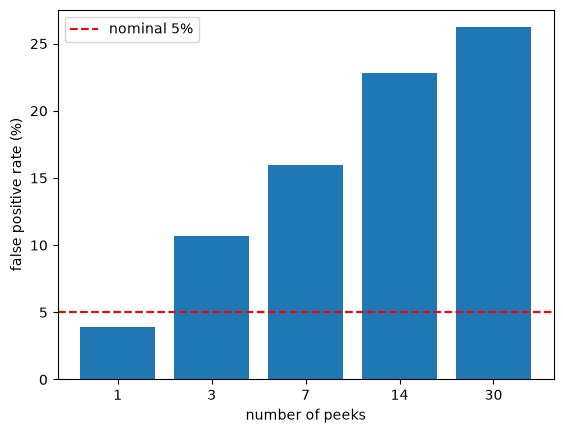

In [4]:
plt.bar([str(k) for k in peeks], [r * 100 for r in rates])
plt.axhline(5, color="red", linestyle="--", label="nominal 5%")
plt.xlabel("number of peeks")
plt.ylabel("false positive rate (%)")
plt.legend()
plt.show()